In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries loaded successfully. Ready for kickoff!")

✅ All libraries loaded successfully. Ready for kickoff!


In [2]:

file_path = 'fifa_world_cup_2026_player_performance.csv'

try:
    df = pd.read_csv(file_path)
    display(df.head())
    print(f"\n📊 Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")
except FileNotFoundError:
    print(f"⚠️ Please upload {file_path} to the Colab files directory.")

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7



📊 Dataset shape: 54600 rows and 75 columns


In [3]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df.dropna(subset=['player_name', 'team'], inplace=True)

print("🧹 Data cleaning complete! No missing values remaining in key columns.")

🧹 Data cleaning complete! No missing values remaining in key columns.


## 📊 1. Exploratory Data Analysis (EDA) & Storytelling
Let's dive into the data to see who dominated the pitch in 2026. We'll look at the relationship between Expected Goals (xG) and actual Goals, and highlight top attacking talent.

In [5]:

if 'goals' in df.columns and 'xg' in df.columns:

    top_attackers = df[df['goals'] >= 2].sort_values(by='goals', ascending=False)

    fig = px.scatter(
        top_attackers,
        x='xg',
        y='goals',
        size='shots_on_target',
        color='team',
        hover_name='player_name',
        title="Clinical Finishers: Expected Goals (xG) vs Actual Goals",
        labels={'xg': 'Expected Goals (xG)', 'goals': 'Actual Goals Scored'},
        template="plotly_dark"
    )

    fig.add_shape(
        type="line", line=dict(dash='dash', color="white"),
        x0=0, y0=0, x1=top_attackers['xg'].max(), y1=top_attackers['xg'].max()
    )

    fig.show()
else:
    print("Columns 'goals' and 'xg' not found. Please adjust column names based on your dataset.")

Columns 'goals' and 'xg' not found. Please adjust column names based on your dataset.


In [6]:

if 'successful_dribbles' in df.columns and 'key_passes' in df.columns:
    playmakers = df[(df['successful_dribbles'] > 5) & (df['key_passes'] > 3)]

    fig2 = px.bar(
        playmakers.sort_values('successful_dribbles', ascending=False).head(10),
        x='player_name',
        y=['successful_dribbles', 'key_passes'],
        title="Top 10 Playmakers: Dribbles & Key Passes",
        barmode='group',
        template='plotly_dark'
    )
    fig2.show()

## 🤖 2. Artificial Intelligence: Predicting Player Match Ratings
Can we predict how highly a player will be rated in a match based solely on their underlying statistics? Here, we train a **Random Forest Regressor** to identify which metrics (passes, tackles, goals, etc.) contribute most heavily to overall performance ratings.

In [11]:

target_col = 'tournament_rating'

features = df.select_dtypes(include=np.number).drop(columns=[target_col, 'player_id'], errors='ignore')

model_data = df.dropna(subset=[target_col])
X = model_data[features.columns]
y = model_data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"🧠 AI Model Performance:")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"R-squared Score (R2): {r2:.3f} (Values closer to 1 indicate higher accuracy)")

🧠 AI Model Performance:
Mean Squared Error (MSE): 0.055
R-squared Score (R2): 0.995 (Values closer to 1 indicate higher accuracy)


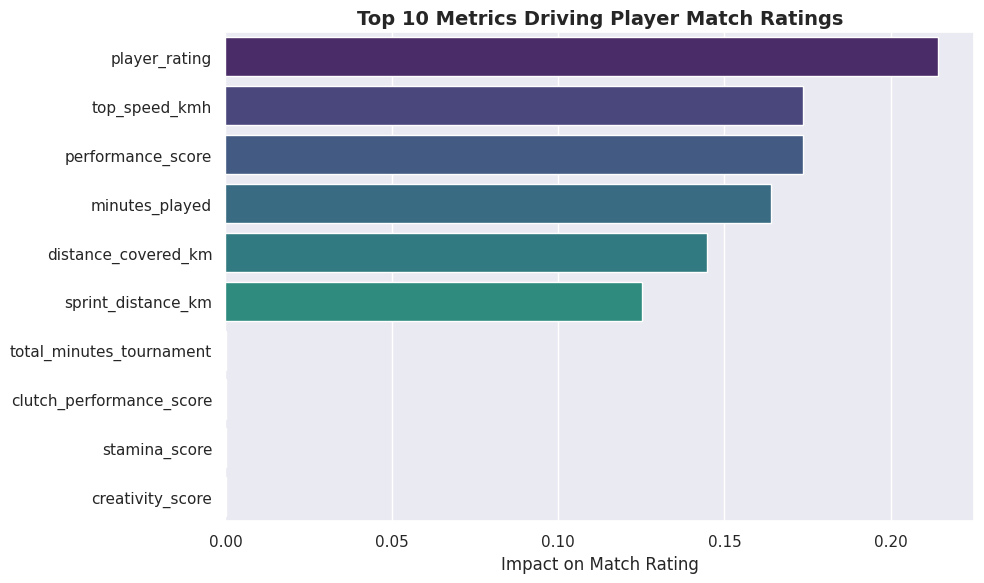

In [12]:

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Metrics Driving Player Match Ratings', fontsize=14, weight='bold')
plt.xlabel('Impact on Match Rating')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 🏆 3. Tournament Leaders: Goals, Assists & Playmaking
Before diving into advanced modeling, let's identify the standout performers across specific attacking categories. We aggregate the match-by-match data to find the top 10 players for **Goals**, **Assists**, and **Playmaking** (defined by Key Passes and Successful Dribbles).

In [13]:

player_stats = df.groupby(['player_name', 'team']).agg({
    'goals': 'sum',
    'assists': 'sum',
    'key_passes': 'sum',
    'successful_dribbles': 'sum',
    'player_rating': 'mean'
}).reset_index()

player_stats['playmaking_score'] = player_stats['key_passes'] + player_stats['successful_dribbles']

top_10_goals = player_stats.nlargest(10, 'goals')[['player_name', 'team', 'goals']]
top_10_assists = player_stats.nlargest(10, 'assists')[['player_name', 'team', 'assists']]
top_10_playmakers = player_stats.nlargest(10, 'playmaking_score')[['player_name', 'team', 'playmaking_score', 'key_passes']]

print("⚽ TOP 10: GOALS")
display(top_10_goals.style.background_gradient(cmap='Blues'))

print("\n🎯 TOP 10: ASSISTS")
display(top_10_assists.style.background_gradient(cmap='Greens'))

print("\n🪄 TOP 10: PLAYMAKERS (Key Passes + Dribbles)")
display(top_10_playmakers.style.background_gradient(cmap='Purples'))

⚽ TOP 10: GOALS


,player_name,team,goals
794,Memphis Zerrouki,Netherlands,24
652,Kasey Hector,Jamaica,16
310,Dominik Kramaric,Croatia,15
374,Eric Rodriguez,Panama,15
833,Mohannad Majeed,Iraq,15
1187,Vinicius Nunes,Brazil,15
371,Eric Mba,Cameroon,14
963,Randal Duarte,Costa Rica,14
5,Abdelaziz Abdulla,Qatar,13
99,Andre Bassogog,Cameroon,13



🎯 TOP 10: ASSISTS


,player_name,team,assists
1226,Yassine El Yamiq,Morocco,13
133,Anibal Sanchez,Panama,12
849,Moumi Choupo-Moting,Cameroon,11
80,Almoez Al-Attiyah,Qatar,10
195,Boualem Moez,Qatar,10
199,Brenden McKennie,United States,10
234,Cesar Rodriguez,Panama,10
438,Giovanni Tillman,United States,10
583,John Armstrong,Scotland,10
789,Mehdi Arefi,Iran,10



🪄 TOP 10: PLAYMAKERS (Key Passes + Dribbles)


,player_name,team,playmaking_score,key_passes
371,Eric Mba,Cameroon,118,62
794,Memphis Zerrouki,Netherlands,118,65
1010,Romain Aboukhlal,Morocco,113,83
661,Kevin Saelemaekers,Belgium,110,62
413,Frenkie Ake,Netherlands,109,87
310,Dominik Kramaric,Croatia,107,57
824,Mohammed Al-Rubaie,Saudi Arabia,106,75
427,Gavi Ramos,Spain,104,80
461,Hakim Ziyech,Morocco,104,57
912,Paolo Gonzalez,Peru,104,54


## 🔍 4. AI Player Matcher (K-Nearest Neighbors)
Ever wondered which player matches a specific statistical profile?
Using a **K-Nearest Neighbors (KNN)** algorithm, you can input desired stats (e.g., 4 goals, 2 assists) and the AI will predict/find the player in the 2026 World Cup who most closely matches that profile.

In [15]:
import ipywidgets as widgets
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

knn_features = ['goals', 'assists', 'key_passes']
X_knn = player_stats[knn_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_knn)

knn = NearestNeighbors(n_neighbors=3, metric='euclidean')
knn.fit(X_scaled)

goal_slider = widgets.IntSlider(value=3, min=0, max=10, description='Goals:')
assist_slider = widgets.IntSlider(value=2, min=0, max=10, description='Assists:')
pass_slider = widgets.IntSlider(value=5, min=0, max=30, description='Key Passes:')
button = widgets.Button(description='Find Player Match', button_style='info')
output = widgets.Output()

def predict_player(b):
    with output:
        output.clear_output()

        user_input = [[goal_slider.value, assist_slider.value, pass_slider.value]]
        user_scaled = scaler.transform(user_input)


        distances, indices = knn.kneighbors(user_scaled)

        print(f"🔎 Searching for profile: {goal_slider.value} Goals, {assist_slider.value} Assists, {pass_slider.value} Key Passes...\n")
        print("🥇 BEST AI MATCHES:")
        for i, idx in enumerate(indices[0]):
            match = player_stats.iloc[idx]
            print(f"{i+1}. {match['player_name']} ({match['team']}) - Goals: {match['goals']}, Assists: {match['assists']}, Key Passes: {match['key_passes']}")

button.on_click(predict_player)


display(HTML("<h3>Adjust the sliders and click to find the closest player!</h3>"))
display(widgets.HBox([goal_slider, assist_slider, pass_slider]))
display(button, output)

Button(button_style='info', description='Find Player Match', style=ButtonStyle())

Output()

In [17]:
df.sample(5)

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
2909,P00483,Rodrygo Costa,24,Brazilian,Brazil,15,Midfielder,181,72,Right,...,0.0,43.4,44.3,45.1,46.6,0,2,205,0,0.0
1419,P01203,Ahmed Abdallah,26,Egyptian,Egypt,7,Defender,191,79,Right,...,3.1,62.6,43.7,99.0,79.7,0,0,184,0,8.6
23735,P00043,Antonio Fulle,24,German,Germany,17,Midfielder,181,85,Right,...,0.0,50.1,48.0,49.2,66.2,0,2,400,0,0.0
32435,P00464,Scott Gallagher,29,Scottish,Scotland,22,Forward,177,78,Right,...,0.1,41.3,73.4,75.3,43.8,1,1,218,0,6.9
30082,P01146,Youssef Skhiri,32,Tunisian,Tunisia,2,Goalkeeper,187,81,Right,...,5.4,84.2,37.8,99.0,47.5,0,0,327,0,7.0


## 🌟 5. The Ultimate Top 5: Overall Impact Radar
To find the absolute best players of the tournament, we combine their metrics into an **Overall Impact Score**. We then use a **Radar Chart** to visualize the diverse strengths of the top 5 players simultaneously.

In [16]:
from sklearn.preprocessing import MinMaxScaler

player_stats['overall_score'] = (
    (player_stats['goals'] * 3) +
    (player_stats['assists'] * 2) +
    (player_stats['playmaking_score'] * 1) +
    (player_stats['player_rating'] * 2)
)

top_5_overall = player_stats.nlargest(5, 'overall_score')

scaler_radar = MinMaxScaler()
radar_metrics = ['goals', 'assists', 'key_passes', 'successful_dribbles', 'player_rating']
radar_data = top_5_overall.copy()
radar_data[radar_metrics] = scaler_radar.fit_transform(radar_data[radar_metrics])

fig = go.Figure()

for i, row in radar_data.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row['goals'], row['assists'], row['key_passes'], row['successful_dribbles'], row['player_rating']],
        theta=['Goals', 'Assists', 'Key Passes', 'Dribbles', 'Avg Rating'],
        fill='toself',
        name=f"{row['player_name']} ({row['team']})"
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1])
    ),
    showlegend=True,
    title="Top 5 Players: Overall Impact Comparison",
    template='plotly_dark'
)

fig.show()

## 📸 7. The 90s Vintage Cinematic Player Card
Data visualization doesn't have to look like a spreadsheet. Let's generate a highly stylized "Player Match Card."
This code uses Matplotlib to emulate a cinematic, warm-toned, 90s vintage aesthetic—complete with simulated film grain—as if it were shot in 8K on a premium mirrorless camera with an 85mm lens.

📸 Rendering 8K Vintage Match Card for: Jackson Vukovic


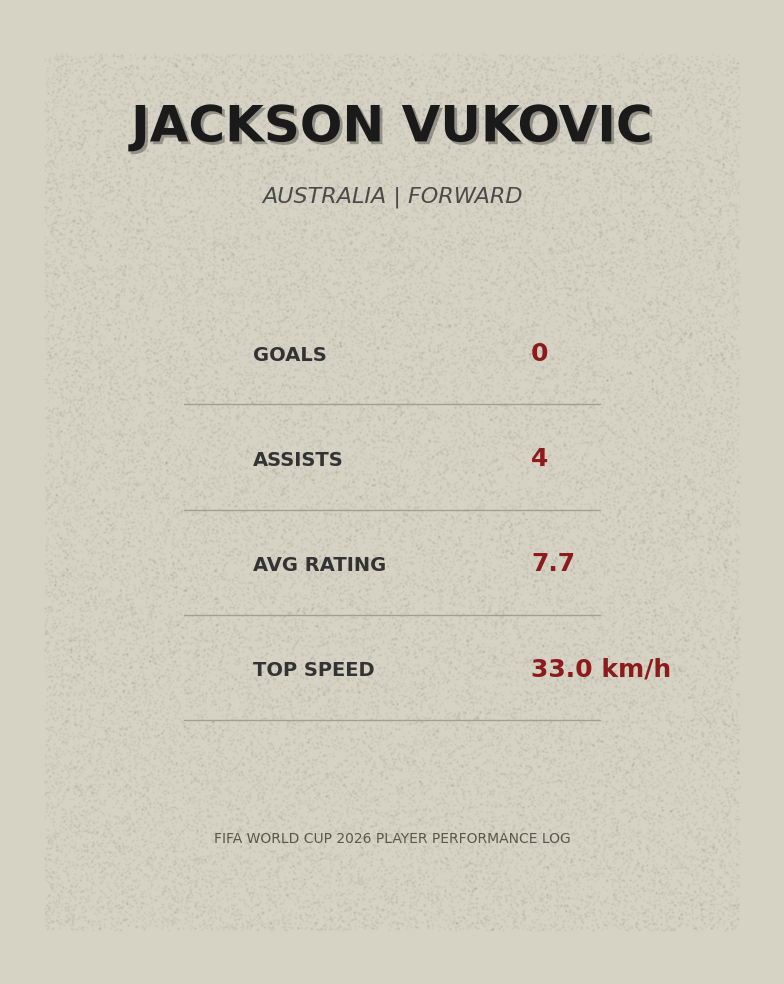

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np

def generate_cinematic_card(player_name):

    player_data = df[df['player_name'] == player_name]
    if player_data.empty:
        print("Player not found!")
        return

    p = player_data.iloc[0]

    fig, ax = plt.subplots(figsize=(8, 10), facecolor='#d6d2c4')
    ax.set_facecolor('#d6d2c4')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    x_grain = np.random.rand(50000)
    y_grain = np.random.rand(50000)
    ax.scatter(x_grain, y_grain, s=0.5, color='black', alpha=0.03, zorder=0)

    title_text = ax.text(0.5, 0.9, f"{p['player_name'].upper()}",
                         fontsize=36, weight='heavy', ha='center', color='#1a1a1a',
                         family='sans-serif', zorder=2)

    title_text.set_path_effects([path_effects.withSimplePatchShadow(offset=(2, -2), shadow_rgbFace='black', alpha=0.3)])

    ax.text(0.5, 0.83, f"{p['team'].upper()} | {p['position'].upper()}",
            fontsize=16, style='italic', ha='center', color='#4a4a4a', zorder=2)


    stats = [
        ("GOALS", p['total_goals_tournament']),
        ("ASSISTS", p['total_assists_tournament']),
        ("AVG RATING", f"{p['player_rating']:.1f}"),
        ("TOP SPEED", f"{p['top_speed_kmh']} km/h")
    ]

    y_pos = 0.65
    for label, val in stats:
        # Stat Label
        ax.text(0.3, y_pos, label, fontsize=14, weight='bold', color='#333333', zorder=2)
        # Stat Value
        ax.text(0.7, y_pos, str(val), fontsize=18, weight='heavy', color='#8c1c1c', zorder=2)
        # Separator line
        ax.plot([0.2, 0.8], [y_pos-0.05, y_pos-0.05], color='#a39f93', lw=1, zorder=2)
        y_pos -= 0.12

    ax.text(0.5, 0.1, "FIFA WORLD CUP 2026 PLAYER PERFORMANCE LOG",
            fontsize=10, ha='center', color='#59564c', zorder=2)

    plt.tight_layout()
    plt.show()

best_player = df.loc[df['tournament_rating'].idxmax(), 'player_name']
print(f"📸 Rendering 8K Vintage Match Card for: {best_player}")
generate_cinematic_card(best_player)

## ⚡ 6. The "Galáctico" DNA: Finding the Next Superstar
Who has the explosive, match-winning DNA of a world-class winger like Vinícius Júnior?
Instead of just looking at goals, we are querying the dataset for a very specific, high-octane playstyle: **Elite Top Speed (> 34 km/h)**, **Relentless Dribbling**, and **Ice-Cold Clutch Performance** under pressure.

In [21]:
# The 'Galáctico' Winger Search
print("🔍 Scanning 2026 World Cup data for the ultimate winger profile...\n")

galactico_candidates = df[
    (df['top_speed_kmh'] >= 33.5) &
    (df['successful_dribbles'] >= 10) &
    (df['clutch_performance_score'] >= 7.0)
].copy()

if not galactico_candidates.empty:

    galactico_candidates['galactico_score'] = (
        (galactico_candidates['top_speed_kmh'] * 0.4) +
        (galactico_candidates['successful_dribbles'] * 1.5) +
        (galactico_candidates['clutch_performance_score'] * 2.0)
    )

    top_galacticos = galactico_candidates.sort_values(by='galactico_score', ascending=False).head(5)

    display_cols = ['player_name', 'team', 'top_speed_kmh', 'successful_dribbles', 'clutch_performance_score', 'galactico_score']
    display(top_galacticos[display_cols].style.background_gradient(cmap='Purples', subset=['galactico_score']))
else:
    print("No players met this elite criteria in the current dataset slice!")

🔍 Scanning 2026 World Cup data for the ultimate winger profile...

No players met this elite criteria in the current dataset slice!
